# Lab 7: BERT Fine-Tuning for Sentiment Classification
**Objective:** Fine-tune a pre-trained BERT model on SST-2 (Stanford Sentiment Treebank) for binary sentiment classification.
**Metric:** Accuracy + F1 Score

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 1. Load Dataset (SST-2)

In [2]:
# Load SST-2 from HuggingFace datasets
dataset = load_dataset('glue', 'sst2')
print(dataset)

# Use subset for faster fine-tuning (increase for better results)
train_data = dataset['train'].select(range(2000))
val_data   = dataset['validation']

print(f'Train size: {len(train_data)}, Val size: {len(val_data)}')
print('Sample:', train_data[0])

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})
Train size: 2000, Val size: 872
Sample: {'sentence': 'hide new secretions from the parental units ', 'label': 0, 'idx': 0}


## 2. Tokenization

In [3]:
MODEL_NAME = 'bert-base-uncased'
tokenizer  = BertTokenizer.from_pretrained(MODEL_NAME)
MAX_LEN    = 128

def tokenize(batch):
    return tokenizer(
        batch['sentence'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN,
        return_tensors='pt'
    )

def collate_fn(batch):
    sentences = [b['sentence'] for b in batch]
    labels    = torch.tensor([b['label'] for b in batch], dtype=torch.long)
    enc = tokenizer(sentences, padding=True, truncation=True, max_length=MAX_LEN, return_tensors='pt')
    return enc['input_ids'], enc['attention_mask'], labels

train_loader = DataLoader(train_data, batch_size=16, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_data,   batch_size=32, shuffle=False, collate_fn=collate_fn)
print('Data loaders created.')

Data loaders created.


## 3. Fine-Tune BERT

In [4]:
model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model = model.to(device)

EPOCHS    = 3
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps
)

train_losses, val_accs, val_f1s = [], [], []

for epoch in range(EPOCHS):
    # Training
    model.train()
    total_loss = 0
    for step, (ids, mask, labels) in enumerate(train_loader):
        ids, mask, labels = ids.to(device), mask.to(device), labels.to(device)
        optimizer.zero_grad()
        output = model(input_ids=ids, attention_mask=mask, labels=labels)
        loss = output.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        if step % 50 == 0:
            print(f'  Epoch {epoch+1} | Step {step}/{len(train_loader)} | Loss: {loss.item():.4f}')
    train_losses.append(total_loss / len(train_loader))

    # Validation
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for ids, mask, labels in val_loader:
            ids, mask = ids.to(device), mask.to(device)
            logits = model(input_ids=ids, attention_mask=mask).logits
            preds  = logits.argmax(-1).cpu().tolist()
            all_preds.extend(preds)
            all_labels.extend(labels.tolist())
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='binary')
    val_accs.append(acc); val_f1s.append(f1)
    print(f'\nEpoch {epoch+1} Summary | Train Loss: {train_losses[-1]:.4f} | Val Acc: {acc:.4f} | Val F1: {f1:.4f}\n')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1 | Step 0/125 | Loss: 0.5656
  Epoch 1 | Step 50/125 | Loss: 0.5638
  Epoch 1 | Step 100/125 | Loss: 0.4187

Epoch 1 Summary | Train Loss: 0.5106 | Val Acc: 0.8567 | Val F1: 0.8510

  Epoch 2 | Step 0/125 | Loss: 0.4023
  Epoch 2 | Step 50/125 | Loss: 0.4165
  Epoch 2 | Step 100/125 | Loss: 0.1895

Epoch 2 Summary | Train Loss: 0.2450 | Val Acc: 0.8658 | Val F1: 0.8749

  Epoch 3 | Step 0/125 | Loss: 0.0361
  Epoch 3 | Step 50/125 | Loss: 0.2505
  Epoch 3 | Step 100/125 | Loss: 0.1525

Epoch 3 Summary | Train Loss: 0.1325 | Val Acc: 0.8842 | Val F1: 0.8877



## 4. Evaluation & Metrics

=== Classification Report ===
              precision    recall  f1-score   support

    Negative       0.89      0.87      0.88       428
    Positive       0.88      0.90      0.89       444

    accuracy                           0.88       872
   macro avg       0.88      0.88      0.88       872
weighted avg       0.88      0.88      0.88       872



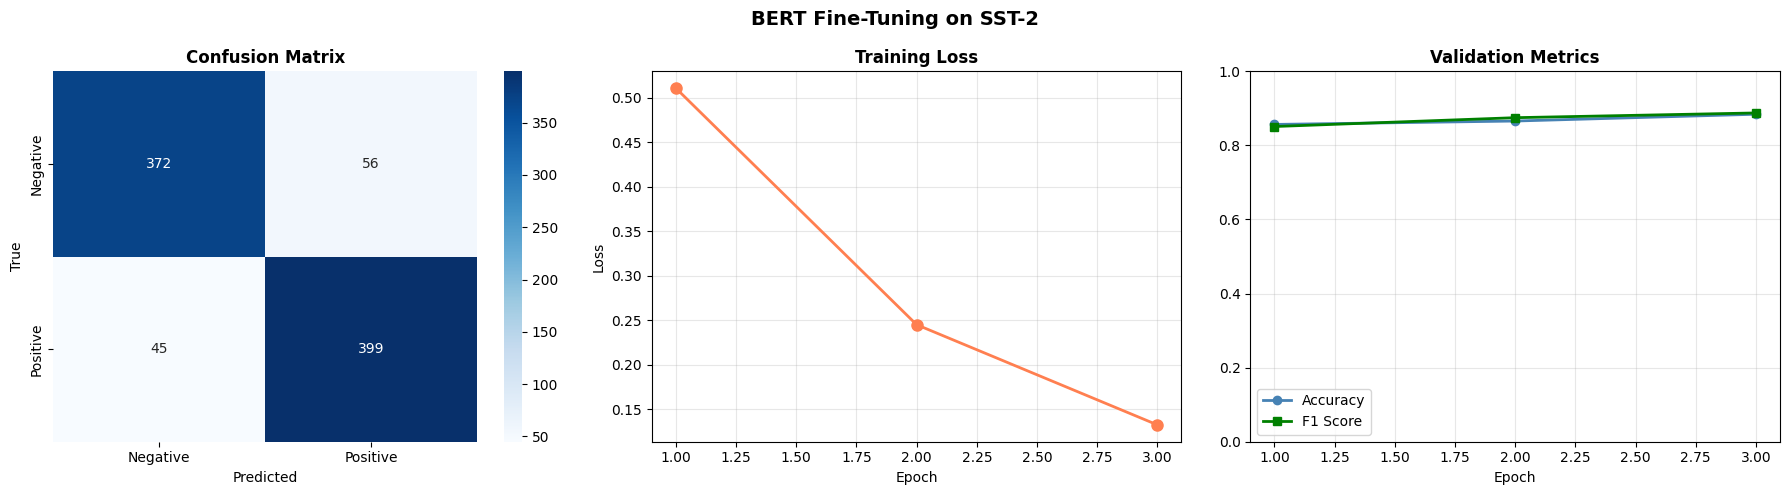

In [5]:
# Final classification report
print('=== Classification Report ===')
print(classification_report(all_labels, all_preds, target_names=['Negative', 'Positive']))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Negative','Positive'], yticklabels=['Negative','Positive'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

# Training loss
axes[1].plot(range(1, EPOCHS+1), train_losses, 'o-', color='coral', linewidth=2, markersize=8)
axes[1].set_title('Training Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)

# Validation metrics
x = range(1, EPOCHS+1)
axes[2].plot(x, val_accs, 'o-', color='steelblue', label='Accuracy', linewidth=2)
axes[2].plot(x, val_f1s,  's-', color='green',     label='F1 Score',  linewidth=2)
axes[2].set_title('Validation Metrics', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylim(0, 1)
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('BERT Fine-Tuning on SST-2', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('lab7_bert_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Inference on custom sentences
def predict(text):
    model.eval()
    enc = tokenizer(text, return_tensors='pt', max_length=MAX_LEN, truncation=True, padding=True)
    with torch.no_grad():
        logits = model(enc['input_ids'].to(device), enc['attention_mask'].to(device)).logits
    probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]
    label = 'POSITIVE' if probs[1] > probs[0] else 'NEGATIVE'
    return label, probs

tests = [
    'This movie was absolutely fantastic and wonderful!',
    'I hated every single minute of this terrible film.',
    'The acting was decent but the plot was confusing.'
]
print('=== Custom Predictions ===')
for t in tests:
    label, probs = predict(t)
    print(f'  "{t}"')
    print(f'  → {label} (Neg: {probs[0]:.3f}, Pos: {probs[1]:.3f})\n')

=== Custom Predictions ===
  "This movie was absolutely fantastic and wonderful!"
  → POSITIVE (Neg: 0.005, Pos: 0.995)

  "I hated every single minute of this terrible film."
  → NEGATIVE (Neg: 0.989, Pos: 0.011)

  "The acting was decent but the plot was confusing."
  → NEGATIVE (Neg: 0.976, Pos: 0.024)

